# 03 — EDA: National Trends

**Goal:** Explore England-wide A&E performance from April 2019 to April 2026. Establish the analytical narrative that drives the rest of the project.

**Data source:** `data/processed/national_monthly.csv` (85 months × 22 columns)

**Outputs:** Charts saved to `outputs/figures/`

**The analytical question this notebook answers:**  
*A&E attendances have recovered to pre-COVID levels — so why hasn't 4-hour performance recovered with them?*

The answer has two parts:
1. Patients arriving are sicker on average (higher admission rate → more complex pathways)
2. Admitted patients can't leave A&E because there are no available hospital beds (the DToA wait crisis)

We build the evidence for that argument across five chart sequences.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv(
    "../data/processed/national_monthly.csv",
    parse_dates=["period"]
)

# Financial year label helper — April starts a new financial year
def fy(dt):
    if dt.month >= 4:
        return f"{dt.year}-{str(dt.year + 1)[2:]}"
    else:
        return f"{dt.year - 1}-{str(dt.year)[2:]}"

df["financial_year"] = df["period"].apply(fy)

# Chart style defaults
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 10

# Colour constants
C_TOTAL   = "#4878CF"   # steelblue — total / all types
C_TYPE1   = "#D55E00"   # orange-red — Type 1 (major A&E)
C_TARGET  = "#009E73"   # green — 95% target
C_COVID   = "#CC0000"   # red — COVID annotation
C_DTOA4   = "#999999"   # grey — DToA > 4hr
C_DTOA12  = "#CC0000"   # red — DToA > 12hr (crisis metric)

# COVID period boundaries for shaded region
COVID_START = pd.Timestamp("2020-03-01")
COVID_END   = pd.Timestamp("2021-09-01")  # England 'Freedom Day' was July 2021; using Sep as tail

FIG_DIR = "../outputs/figures/"
print(f"Loaded: {df.shape[0]} months, {df['period'].min().date()} → {df['period'].max().date()}")

Loaded: 85 months, 2019-04-01 → 2026-04-01


---
## Part 1 — Attendance Trends

Start with volume: how many people attended A&E each month, and how did COVID disrupt that?

The key distinction is **Total Attendances** (all department types) vs **Type 1 Attendances** (major A&E only). For performance analysis, Type 1 is what matters — the 4-hour standard applies only to Type 1. Total can be used to show overall demand.

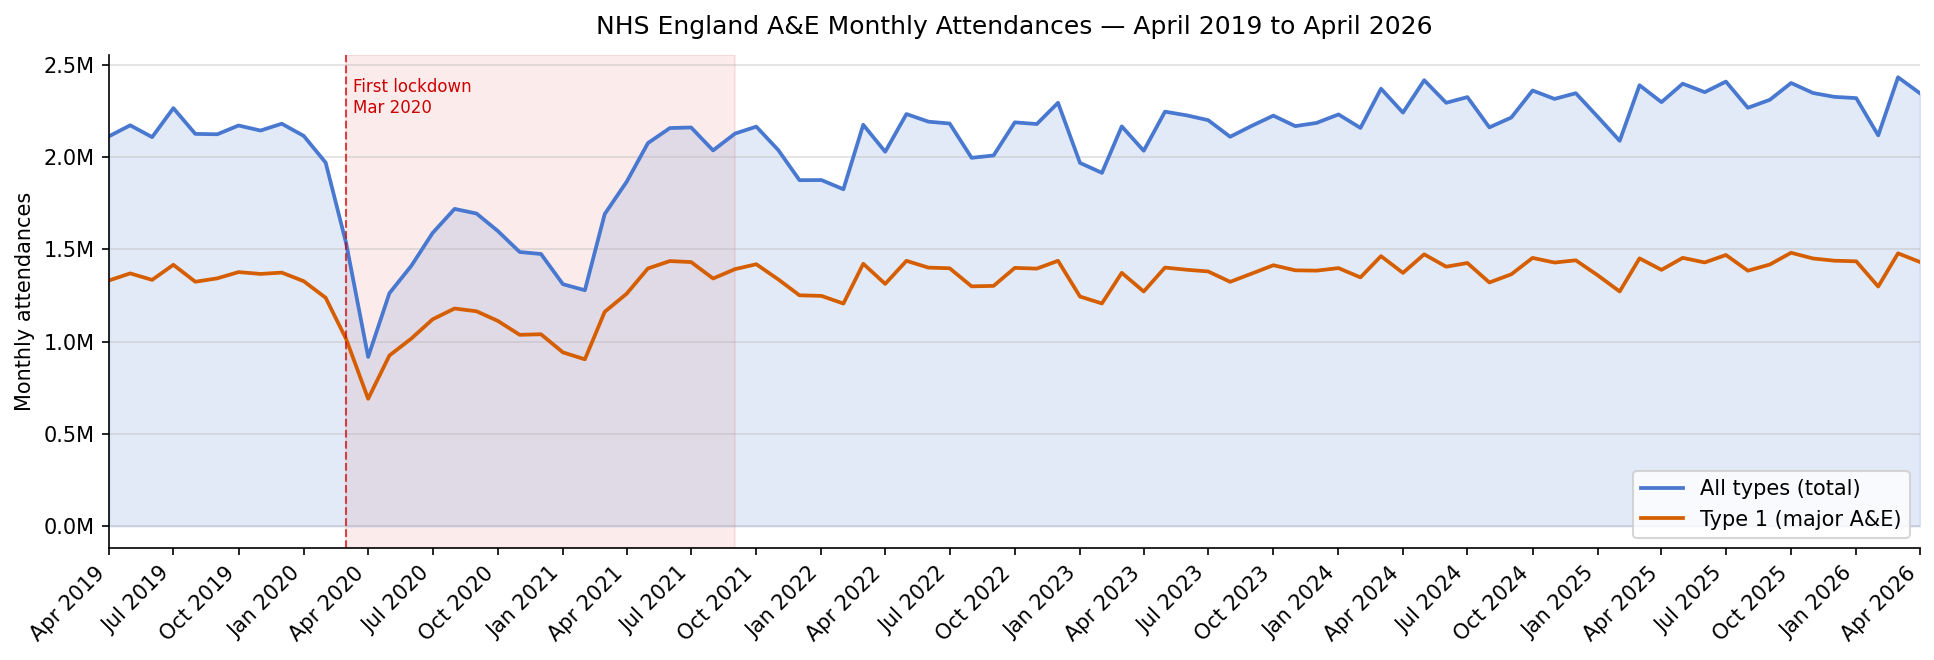

Saved: 03_01_attendance_trend.png


In [2]:
fig, ax = plt.subplots(figsize=(13, 4.5))

ax.fill_between(df["period"], df["total_attendances"] / 1e6, alpha=0.15, color=C_TOTAL)
ax.plot(df["period"], df["total_attendances"] / 1e6,
        color=C_TOTAL, linewidth=1.8, label="All types (total)")
ax.plot(df["period"], df["type1_attendances"] / 1e6,
        color=C_TYPE1, linewidth=1.8, label="Type 1 (major A&E)")

# COVID shaded region
ax.axvspan(COVID_START, COVID_END, alpha=0.08, color=C_COVID, zorder=0)
ax.axvline(COVID_START, color=C_COVID, linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(COVID_START + pd.Timedelta(days=10), ax.get_ylim()[1] * 0.95,
        "First lockdown\nMar 2020", color=C_COVID, fontsize=8, va="top")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.set_ylabel("Monthly attendances")
ax.set_title("NHS England A&E Monthly Attendances — April 2019 to April 2026", fontsize=12, pad=10)
ax.legend(loc="lower right")
ax.set_xlim(df["period"].min(), df["period"].max())
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "03_01_attendance_trend.png", dpi=150)
plt.show()
print("Saved: 03_01_attendance_trend.png")

In [3]:
# Key attendance statistics
pre_covid = df[df["period"] < "2020-03-01"]
covid_min = df.loc[df["type1_attendances"].idxmin()]
latest = df.iloc[-1]

print("=== Attendance key statistics ===")
print(f"Pre-COVID Type 1 monthly avg:  {pre_covid['type1_attendances'].mean():>10,.0f}")
print(f"COVID minimum (month):         {covid_min['type1_attendances']:>10,.0f}  ({covid_min['period'].strftime('%b %Y')})")
print(f"Latest Type 1 (Apr 2026):      {latest['type1_attendances']:>10,.0f}")
print(f"  vs pre-COVID avg:            {latest['type1_attendances'] / pre_covid['type1_attendances'].mean() - 1:>+10.1%}")
print()
print(f"Pre-COVID Total monthly avg:   {pre_covid['total_attendances'].mean():>10,.0f}")
print(f"Latest Total (Apr 2026):       {latest['total_attendances']:>10,.0f}")
print(f"  vs pre-COVID avg:            {latest['total_attendances'] / pre_covid['total_attendances'].mean() - 1:>+10.1%}")

=== Attendance key statistics ===
Pre-COVID Type 1 monthly avg:   1,345,242
COVID minimum (month):            689,720  (Apr 2020)
Latest Type 1 (Apr 2026):       1,430,825
  vs pre-COVID avg:                 +6.4%

Pre-COVID Total monthly avg:    2,135,029
Latest Total (Apr 2026):        2,345,329
  vs pre-COVID avg:                 +9.9%


**What we see:** Type 1 attendances dropped roughly 25% in March 2020 at the start of the first lockdown, with the deepest trough in April/May 2020. By 2021-22 they had recovered to pre-COVID levels, and by 2024-25 they slightly exceed them. The demand story is one of recovery — not a permanently smaller A&E.

---
## Part 2 — 4-Hour Performance

The 4-hour standard — that 95% of Type 1 patients are seen, treated, and discharged or admitted within 4 hours — has been the NHS's primary A&E performance target since 2004. England has not consistently met it since about 2014, and it has worsened significantly since 2021.

**Note on the 2020-21 spike:** When you look at the chart, performance appears to *improve* during COVID. This is misleading. The denominator (attendances) collapsed faster than the numerator (patients seen within 4hr), making the ratio look better. It's a statistical artefact, not a real improvement — the system became less pressured because fewer people came in, not because it got better at treating them.

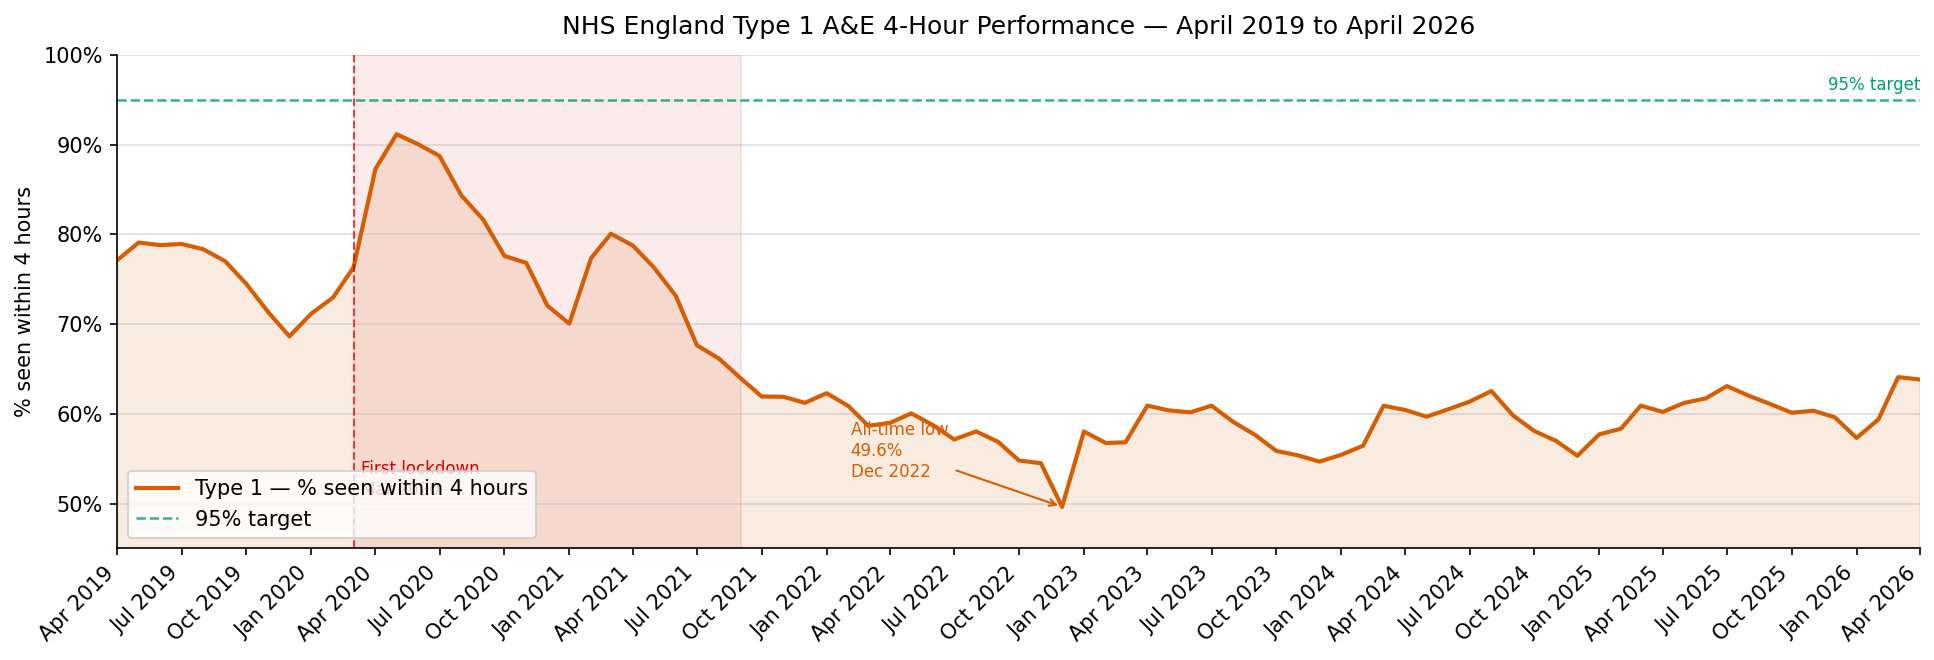

Saved: 03_02_performance_trend.png


In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))

ax.fill_between(df["period"], df["pct_4hr_type1"] * 100, alpha=0.12, color=C_TYPE1)
ax.plot(df["period"], df["pct_4hr_type1"] * 100,
        color=C_TYPE1, linewidth=2.0, label="Type 1 — % seen within 4 hours")

# 95% target line
ax.axhline(95, color=C_TARGET, linestyle="--", linewidth=1.2, alpha=0.8, label="95% target")
ax.text(df["period"].max(), 95.6, "95% target", color=C_TARGET, fontsize=8, ha="right", va="bottom")

# COVID shaded region
ax.axvspan(COVID_START, COVID_END, alpha=0.08, color=C_COVID, zorder=0)
ax.axvline(COVID_START, color=C_COVID, linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(COVID_START + pd.Timedelta(days=10), 50.5,
        "First lockdown\nMar 2020", color=C_COVID, fontsize=8, va="bottom")

# Annotate the all-time low
min_row = df.loc[df["pct_4hr_type1"].idxmin()]
ax.annotate(
    f"All-time low\n{min_row['pct_4hr_type1']:.1%}\n{min_row['period'].strftime('%b %Y')}",
    xy=(min_row["period"], min_row["pct_4hr_type1"] * 100),
    xytext=(min_row["period"] - pd.Timedelta(days=300), 53),
    fontsize=8, color=C_TYPE1,
    arrowprops=dict(arrowstyle="->", color=C_TYPE1, lw=1.0)
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylabel("% seen within 4 hours")
ax.set_ylim(45, 100)
ax.set_title("NHS England Type 1 A&E 4-Hour Performance — April 2019 to April 2026", fontsize=12, pad=10)
ax.legend(loc="lower left")
ax.set_xlim(df["period"].min(), df["period"].max())
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "03_02_performance_trend.png", dpi=150)
plt.show()
print("Saved: 03_02_performance_trend.png")

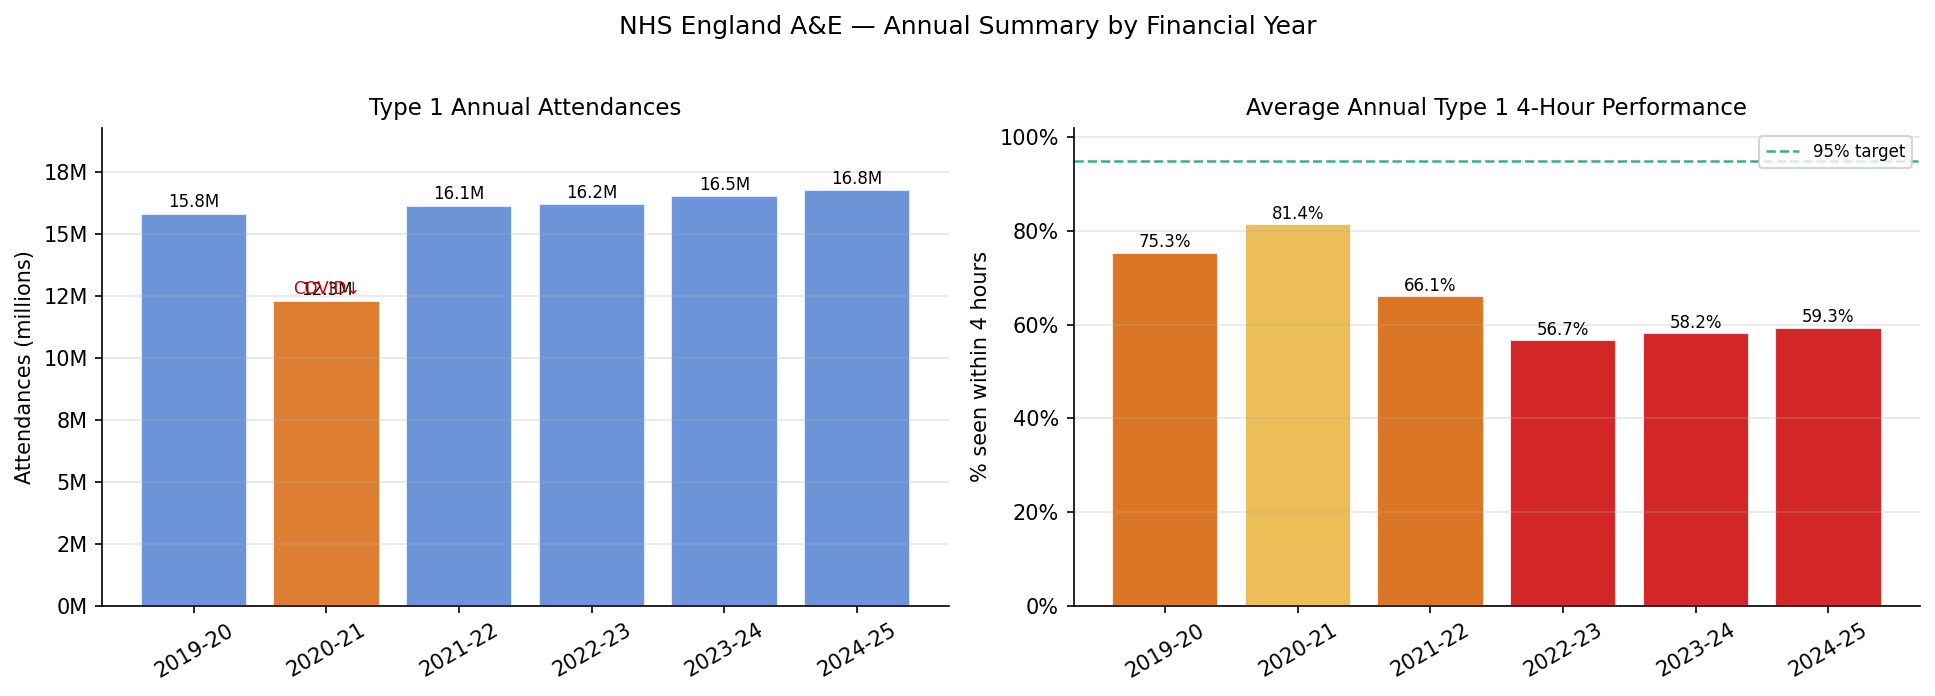

Saved: 03_03_annual_summary.png


In [5]:
# Annual performance summary — 6 complete financial years
COMPLETE_FYS = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
annual = (
    df[df["financial_year"].isin(COMPLETE_FYS)]
    .groupby("financial_year", sort=True)
    .agg(
        type1_ann=   ("type1_attendances",  "sum"),
        pct_avg=     ("pct_4hr_type1",       "mean"),
        pct_min=     ("pct_4hr_type1",       "min"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: annual Type 1 attendances
bars = axes[0].bar(annual["financial_year"], annual["type1_ann"] / 1e6,
                   color=["#D55E00" if fy == "2020-21" else "#4878CF" for fy in annual["financial_year"]],
                   alpha=0.8, edgecolor="white")
for bar, val in zip(bars, annual["type1_ann"] / 1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val:.1f}M", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Type 1 Annual Attendances", fontsize=11)
axes[0].set_ylabel("Attendances (millions)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
axes[0].set_ylim(0, annual["type1_ann"].max() / 1e6 * 1.15)
axes[0].tick_params(axis="x", rotation=30)
axes[0].text(1, annual["type1_ann"].iloc[1] / 1e6 + 0.3, "COVID↓",
             ha="center", fontsize=8, color="#CC0000")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", alpha=0.3)

# Right: average annual 4-hour performance
bar_colours = ["#5AAB61" if p >= 0.95 else ("#E8B33A" if p >= 0.80 else
               ("#D55E00" if p >= 0.65 else "#CC0000")) for p in annual["pct_avg"]]
bars2 = axes[1].bar(annual["financial_year"], annual["pct_avg"] * 100,
                    color=bar_colours, alpha=0.85, edgecolor="white")
for bar, val in zip(bars2, annual["pct_avg"] * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=8)
axes[1].axhline(95, color=C_TARGET, linestyle="--", linewidth=1.2, alpha=0.8, label="95% target")
axes[1].set_title("Average Annual Type 1 4-Hour Performance", fontsize=11)
axes[1].set_ylabel("% seen within 4 hours")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].set_ylim(0, 102)
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right", fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("NHS England A&E — Annual Summary by Financial Year", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + "03_03_annual_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_03_annual_summary.png")

**What we see:** Performance was already at 75.3% on average in 2019-20 — 20 percentage points below the 95% target. The apparent 2020-21 improvement to 81.4% is a COVID artefact (fewer patients, cleared backlog). From 2021-22 onwards, as demand recovered, performance crashed: 66.1% → 56.7% → 58.2% → 59.3%. England averaged below 60% for three consecutive financial years. It has not been within 10pp of the 95% target since 2019-20.

---
## Part 3 — The Divergence: Indexed Comparison

To show that volume recovered but performance did not, we index both series to April 2019 = 100. If both had recovered together, the lines would track each other. The gap between them is the analytical core of this project.

An indexed chart (also called a rebased chart or index chart) is a standard technique in economic and policy analysis when you want to compare the *rate of change* of two things that are measured in different units — here, attendance counts vs. a percentage.

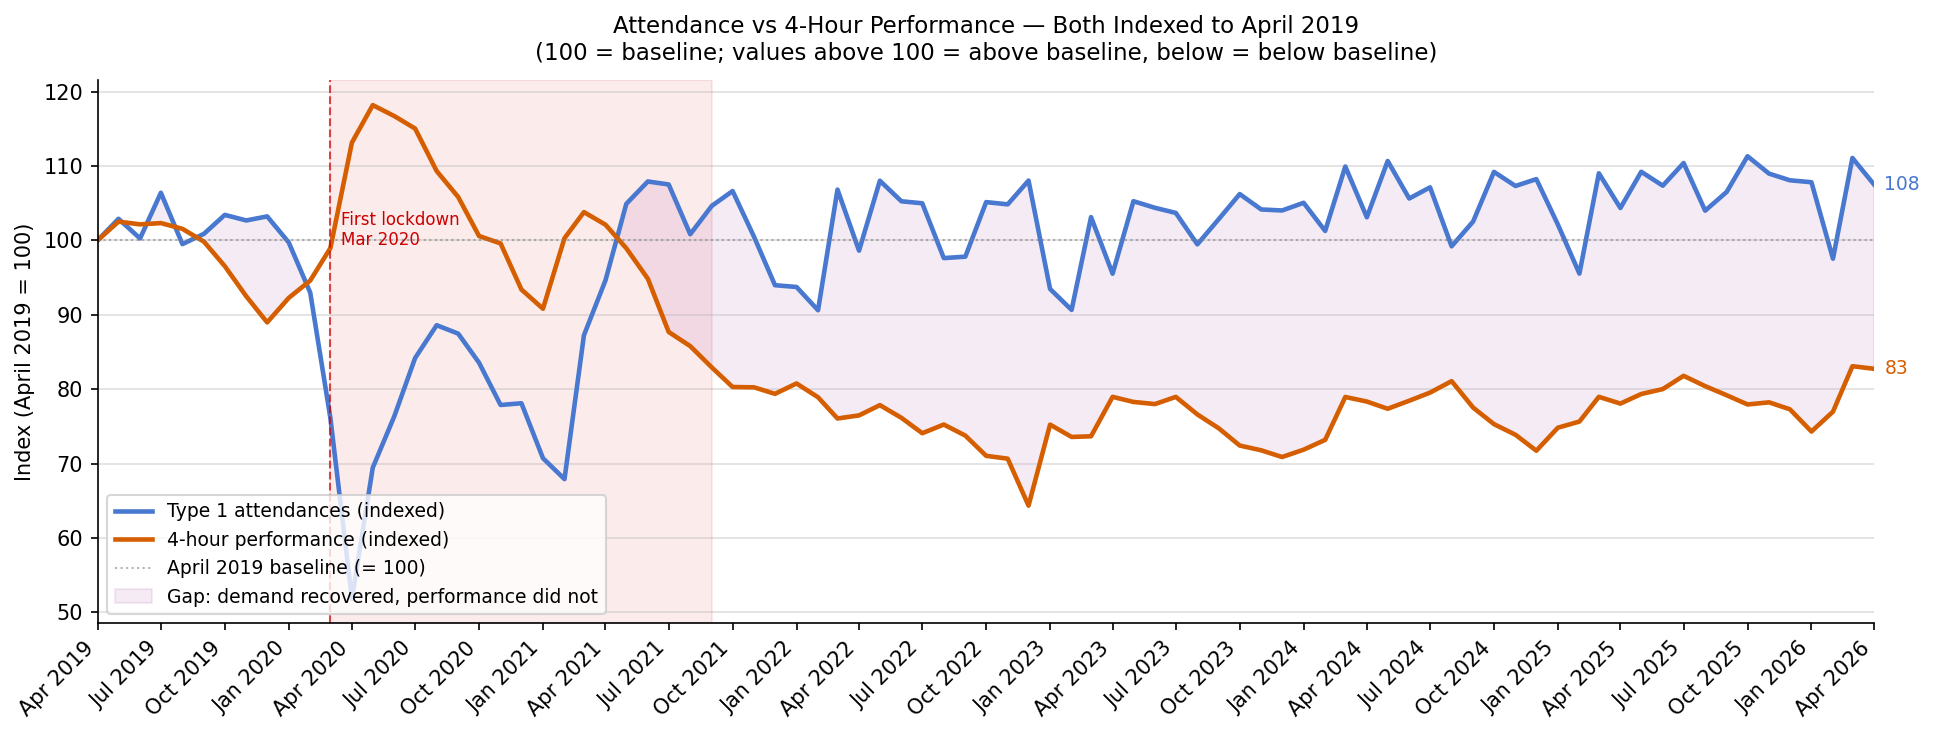

Saved: 03_04_indexed_divergence.png

April 2026 attendance index: 107.5  (demand +7.5% vs Apr 2019)
April 2026 performance index:82.7  (performance -17.3% vs Apr 2019)


In [6]:
# Rebase to April 2019 = 100
base = df[df["period"] == "2019-04-01"].iloc[0]
df["type1_idx"] = df["type1_attendances"] / base["type1_attendances"] * 100
df["perf_idx"]  = df["pct_4hr_type1"]    / base["pct_4hr_type1"]    * 100

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df["period"], df["type1_idx"],
        color=C_TOTAL, linewidth=2.2, label="Type 1 attendances (indexed)")
ax.plot(df["period"], df["perf_idx"],
        color=C_TYPE1, linewidth=2.2, label="4-hour performance (indexed)")

# Baseline reference
ax.axhline(100, color="grey", linestyle=":", linewidth=1.0, alpha=0.6, label="April 2019 baseline (= 100)")

# COVID shaded region
ax.axvspan(COVID_START, COVID_END, alpha=0.08, color=C_COVID, zorder=0)
ax.axvline(COVID_START, color=C_COVID, linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(COVID_START + pd.Timedelta(days=15), 104,
        "First lockdown\nMar 2020", color=C_COVID, fontsize=8, va="top")

# Shade the divergence gap (fill between the two lines)
ax.fill_between(df["period"], df["type1_idx"], df["perf_idx"],
                where=df["type1_idx"] >= df["perf_idx"],
                interpolate=True, alpha=0.08, color="purple",
                label="Gap: demand recovered, performance did not")

# Annotate final values
last = df.iloc[-1]
ax.annotate(f"{last['type1_idx']:.0f}",
            xy=(last["period"], last["type1_idx"]),
            xytext=(5, 0), textcoords="offset points",
            fontsize=9, color=C_TOTAL, va="center")
ax.annotate(f"{last['perf_idx']:.0f}",
            xy=(last["period"], last["perf_idx"]),
            xytext=(5, 0), textcoords="offset points",
            fontsize=9, color=C_TYPE1, va="center")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax.set_ylabel("Index (April 2019 = 100)")
ax.set_title(
    "Attendance vs 4-Hour Performance — Both Indexed to April 2019\n"
    "(100 = baseline; values above 100 = above baseline, below = below baseline)",
    fontsize=11, pad=10
)
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim(df["period"].min(), df["period"].max())
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "03_04_indexed_divergence.png", dpi=150)
plt.show()
print("Saved: 03_04_indexed_divergence.png")
print()
print(f"April 2026 attendance index: {last['type1_idx']:.1f}  (demand {last['type1_idx']-100:+.1f}% vs Apr 2019)")
print(f"April 2026 performance index:{last['perf_idx']:.1f}  (performance {last['perf_idx']-100:+.1f}% vs Apr 2019)")

---
## Part 4 — Emergency Admission Rate

If more of the patients arriving at Type 1 A&E need to be admitted, the department's throughput problem becomes structural — every admitted patient is taking up space and staff time until a bed is found. The **admission rate** (emergency admissions via Type 1 ÷ Type 1 attendances) is a proxy for average patient acuity.

A rising admission rate means the A&E patient mix is skewing sicker — more of the people who are attending genuinely need a hospital bed, not just a quick assessment and discharge.

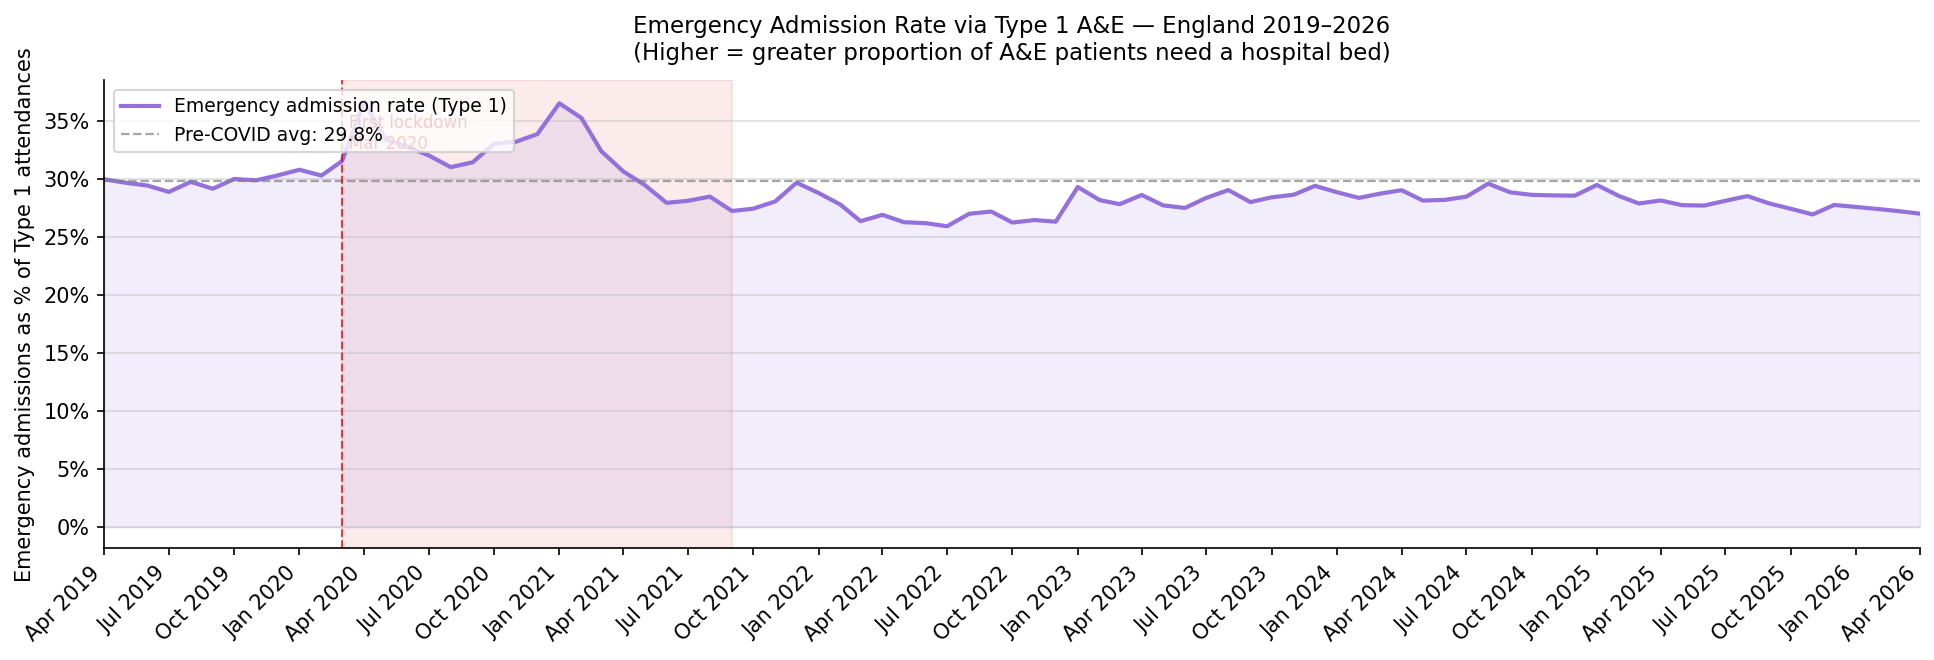

Saved: 03_05_admission_rate.png

Pre-COVID average admission rate: 29.8%
Latest (Apr 2026) admission rate: 27.0%
Change:                           -2.8%


In [7]:
df["admission_rate"] = df["emerg_admissions_type1"] / df["type1_attendances"]

pre_covid_rate = df[df["period"] < "2020-03-01"]["admission_rate"].mean()
latest_rate    = df.iloc[-1]["admission_rate"]

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.fill_between(df["period"], df["admission_rate"] * 100, alpha=0.12, color="#9370DB")
ax.plot(df["period"], df["admission_rate"] * 100,
        color="#9370DB", linewidth=2.0, label="Emergency admission rate (Type 1)")

# Pre-COVID average reference line
ax.axhline(pre_covid_rate * 100, color="grey", linestyle="--", linewidth=1.1,
           alpha=0.7, label=f"Pre-COVID avg: {pre_covid_rate:.1%}")

# COVID shaded region
ax.axvspan(COVID_START, COVID_END, alpha=0.08, color=C_COVID, zorder=0)
ax.axvline(COVID_START, color=C_COVID, linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(COVID_START + pd.Timedelta(days=10),
        df["admission_rate"].max() * 100 * 0.97,
        "First lockdown\nMar 2020", color=C_COVID, fontsize=8, va="top")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylabel("Emergency admissions as % of Type 1 attendances")
ax.set_title(
    "Emergency Admission Rate via Type 1 A&E — England 2019–2026\n"
    "(Higher = greater proportion of A&E patients need a hospital bed)",
    fontsize=11, pad=10
)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(df["period"].min(), df["period"].max())
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "03_05_admission_rate.png", dpi=150)
plt.show()
print("Saved: 03_05_admission_rate.png")
print()
print(f"Pre-COVID average admission rate: {pre_covid_rate:.1%}")
print(f"Latest (Apr 2026) admission rate: {latest_rate:.1%}")
print(f"Change:                           {latest_rate - pre_covid_rate:+.1%}")

---
## Part 5 — The Bed Crisis: Decision-to-Admit (DToA) Waits

The DToA wait is a *separate* metric from the 4-hour standard, but it's the single most important driver of A&E performance collapse.

**What it measures:** After a clinician in A&E decides a patient needs to be admitted to a hospital ward, how long does that patient wait before physically getting to a bed? This wait happens *after* the A&E treatment decision, while the patient remains in A&E occupying a trolley or space.

**Why it matters so much:** Every patient waiting for a bed is blocking capacity in A&E. They're still in the department, consuming staff attention, occupying physical space. This directly prevents new patients from being assessed promptly — which is exactly what the 4-hour clock measures.

**The pre-COVID baseline:** DToA > 12hr waits were essentially negligible before COVID — about 1,000 per month nationally.

**What happened from 2021 onwards:** As social care capacity shrunk (care home places, home care packages), many patients who were medically ready to leave hospital couldn't do so. This backed up wards, which backed up admissions, which backed up A&E. The 12-hour DToA wait went from 1,000 to over 70,000 per month.

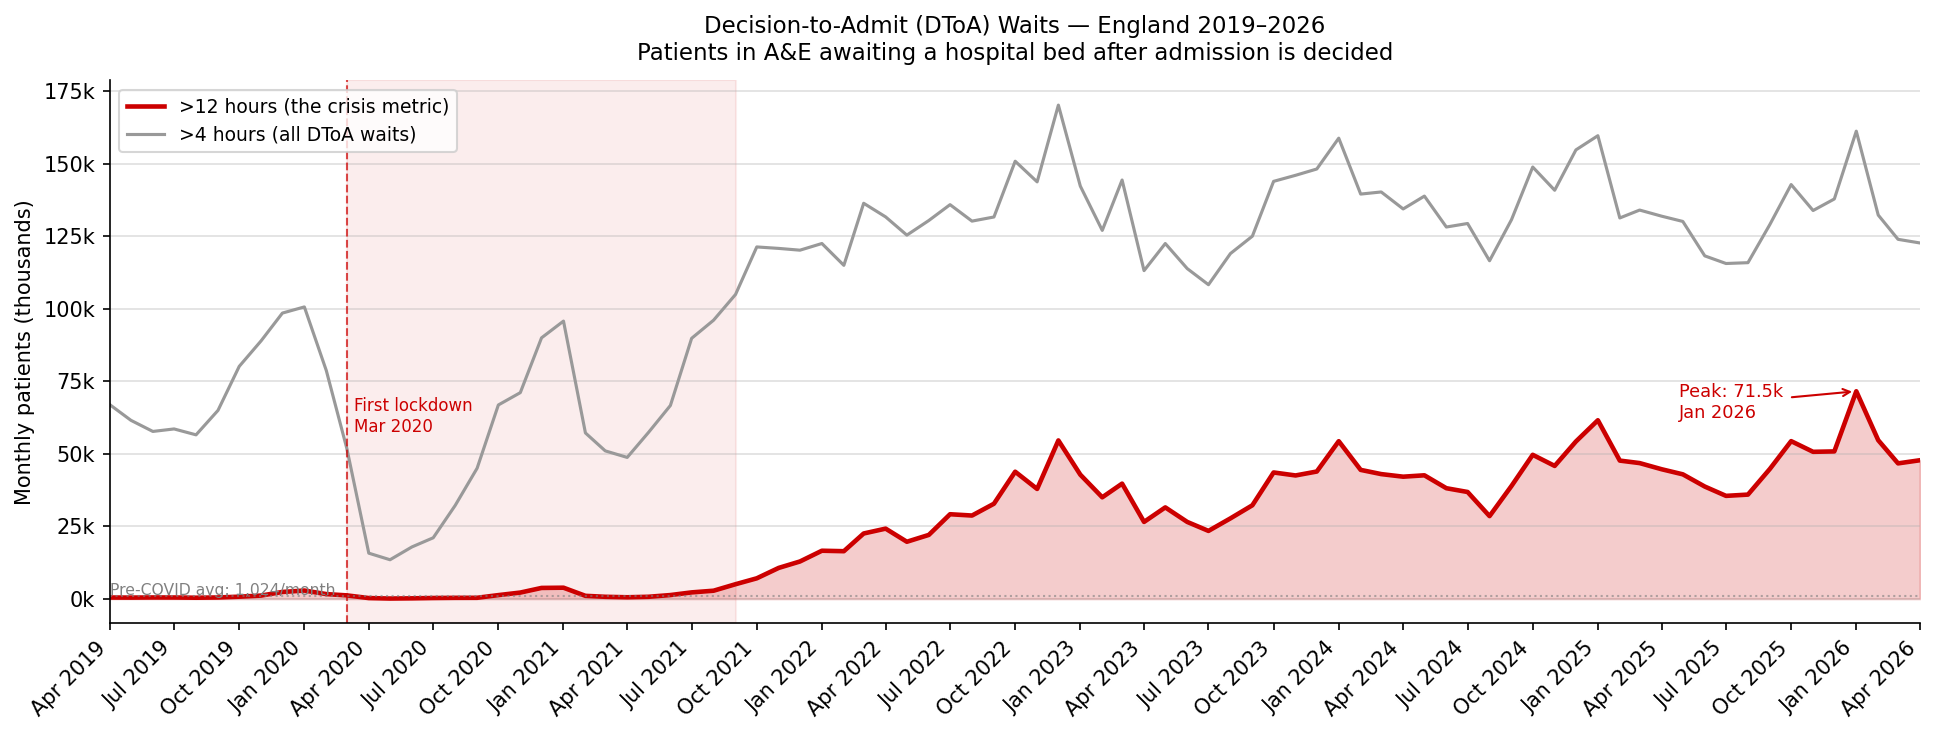

Saved: 03_06_dtoa_waits.png

Pre-COVID >12hr DToA avg:     1,024 / month
Peak >12hr DToA:             71,517 / month  (Jan 2026)
Latest >12hr DToA:           47,750 / month  (Apr 2026)
Increase (latest vs pre-COVID avg): 47×


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(df["period"], df["dtoa_over_12hr"] / 1000, alpha=0.2, color=C_DTOA12)
ax.plot(df["period"], df["dtoa_over_12hr"] / 1000,
        color=C_DTOA12, linewidth=2.2, label=">12 hours (the crisis metric)")
ax.plot(df["period"], df["dtoa_over_4hr"] / 1000,
        color=C_DTOA4, linewidth=1.5, linestyle="-", label=">4 hours (all DToA waits)")

# COVID shaded region
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color=C_COVID, zorder=0)
ax.axvline(COVID_START, color=C_COVID, linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(COVID_START + pd.Timedelta(days=10),
        df["dtoa_over_12hr"].max() / 1000 * 0.97,
        "First lockdown\nMar 2020", color=C_COVID, fontsize=8, va="top")

# Annotate peak
peak_row = df.loc[df["dtoa_over_12hr"].idxmax()]
ax.annotate(
    f"Peak: {peak_row['dtoa_over_12hr']/1000:.1f}k\n{peak_row['period'].strftime('%b %Y')}",
    xy=(peak_row["period"], peak_row["dtoa_over_12hr"] / 1000),
    xytext=(peak_row["period"] - pd.Timedelta(days=250), peak_row["dtoa_over_12hr"] / 1000 * 0.87),
    fontsize=8.5, color=C_DTOA12,
    arrowprops=dict(arrowstyle="->", color=C_DTOA12, lw=1.0)
)

# Pre-COVID baseline annotation
pre_covid_12hr = df[df["period"] < "2020-03-01"]["dtoa_over_12hr"].mean()
ax.axhline(pre_covid_12hr / 1000, color="grey", linestyle=":", linewidth=1.0, alpha=0.6)
ax.text(df["period"].min(), pre_covid_12hr / 1000 + 0.4,
        f"Pre-COVID avg: {pre_covid_12hr:,.0f}/month", fontsize=7.5, color="grey")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.set_ylabel("Monthly patients (thousands)")
ax.set_title(
    "Decision-to-Admit (DToA) Waits — England 2019–2026\n"
    "Patients in A&E awaiting a hospital bed after admission is decided",
    fontsize=11, pad=10
)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(df["period"].min(), df["period"].max())
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "03_06_dtoa_waits.png", dpi=150)
plt.show()
print("Saved: 03_06_dtoa_waits.png")
print()
latest = df.iloc[-1]
print(f"Pre-COVID >12hr DToA avg:  {pre_covid_12hr:>8,.0f} / month")
print(f"Peak >12hr DToA:           {df['dtoa_over_12hr'].max():>8,.0f} / month  ({peak_row['period'].strftime('%b %Y')})")
print(f"Latest >12hr DToA:         {latest['dtoa_over_12hr']:>8,.0f} / month  ({latest['period'].strftime('%b %Y')})")
print(f"Increase (latest vs pre-COVID avg): {latest['dtoa_over_12hr'] / pre_covid_12hr:.0f}×")

---
## Part 6 — Key Findings Summary

Bringing together the evidence from all five chart sequences.

In [9]:
pre_covid   = df[df["period"] < "2020-03-01"]
latest_row  = df.iloc[-1]
worst_perf  = df.loc[df["pct_4hr_type1"].idxmin()]

print("=" * 60)
print("NHS ENGLAND A&E — NATIONAL TRENDS SUMMARY")
print("=" * 60)
print()
print("ATTENDANCE")
print(f"  Pre-COVID avg (Type 1):  {pre_covid['type1_attendances'].mean():>10,.0f} / month")
print(f"  Latest (Apr 2026):       {latest_row['type1_attendances']:>10,.0f} / month")
print(f"  Change vs pre-COVID:     {latest_row['type1_attendances'] / pre_covid['type1_attendances'].mean() - 1:>+9.1%}")
print()
print("4-HOUR PERFORMANCE (Type 1)")
print(f"  95% national target:     {'95.0%':>10}")
print(f"  Pre-COVID avg:           {pre_covid['pct_4hr_type1'].mean():>10.1%}  (already 20pp below target)")
print(f"  All-time low:            {worst_perf['pct_4hr_type1']:>10.1%}  ({worst_perf['period'].strftime('%b %Y')})")
print(f"  Latest (Apr 2026):       {latest_row['pct_4hr_type1']:>10.1%}")
print(f"  Gap to target (latest):  {latest_row['pct_4hr_type1'] - 0.95:>+9.1%}")
print()
print("EMERGENCY ADMISSION RATE")
print(f"  Pre-COVID avg:           {pre_covid['admission_rate'].mean():>10.1%}")
print(f"  Latest (Apr 2026):       {latest_row['admission_rate']:>10.1%}")
print()
print("DToA >12hr WAITS (bed crisis)")
pre_12 = pre_covid['dtoa_over_12hr'].mean()
print(f"  Pre-COVID avg:           {pre_12:>10,.0f} / month")
print(f"  Peak:                    {df['dtoa_over_12hr'].max():>10,.0f} / month  ({df.loc[df['dtoa_over_12hr'].idxmax(), 'period'].strftime('%b %Y')})")
print(f"  Latest (Apr 2026):       {latest_row['dtoa_over_12hr']:>10,.0f} / month")
print(f"  Increase (latest/pre):   {latest_row['dtoa_over_12hr'] / pre_12:>10.0f}×")
print()
print("=" * 60)
print("NARRATIVE CONCLUSION")
print("=" * 60)
print("""
A&E demand has fully recovered and slightly exceeded pre-COVID
levels. But 4-hour performance has not recovered — it averaged
below 60% for three consecutive financial years (2022–2025)
against a 95% target.

Two structural causes:
1. Admission rate has risen — patients are sicker on average,
   meaning more require inpatient admission and more complex care.
2. DToA waits exploded ~47× above pre-COVID levels. Patients who
   need a hospital bed cannot get one, blocking A&E throughput.
   This is a whole-system capacity problem: insufficient hospital
   beds + insufficient social care discharge capacity.

The 4-hour performance gap is not a failure of A&E departments
in isolation — it reflects system-wide capacity constraints
upstream and downstream of the emergency front door.
""")

NHS ENGLAND A&E — NATIONAL TRENDS SUMMARY

ATTENDANCE
  Pre-COVID avg (Type 1):   1,345,242 / month
  Latest (Apr 2026):        1,430,825 / month
  Change vs pre-COVID:         +6.4%

4-HOUR PERFORMANCE (Type 1)
  95% national target:          95.0%
  Pre-COVID avg:                75.3%  (already 20pp below target)
  All-time low:                 49.6%  (Dec 2022)
  Latest (Apr 2026):            63.8%
  Gap to target (latest):     -31.2%

EMERGENCY ADMISSION RATE
  Pre-COVID avg:                29.8%
  Latest (Apr 2026):            27.0%

DToA >12hr WAITS (bed crisis)
  Pre-COVID avg:                1,024 / month
  Peak:                        71,517 / month  (Jan 2026)
  Latest (Apr 2026):           47,750 / month
  Increase (latest/pre):           47×

NARRATIVE CONCLUSION

A&E demand has fully recovered and slightly exceeded pre-COVID
levels. But 4-hour performance has not recovered — it averaged
below 60% for three consecutive financial years (2022–2025)
against a 95% target.

Two 

---
## Charts produced

| File | Description |
|---|---|
| `03_01_attendance_trend.png` | Monthly A&E attendances (total + Type 1) with COVID annotation |
| `03_02_performance_trend.png` | Type 1 4-hour performance with 95% target and all-time low annotated |
| `03_03_annual_summary.png` | Annual summary: attendances and performance by financial year (bar charts) |
| `03_04_indexed_divergence.png` | Attendance and performance indexed to Apr 2019 — shows divergence |
| `03_05_admission_rate.png` | Emergency admission rate (admissions/attendances) as acuity proxy |
| `03_06_dtoa_waits.png` | DToA >4hr and >12hr waits — the bed crisis story |

## Next: Notebook 04 — Trust-Level EDA
Reads from `quarterly_by_provider.csv`. Identifies best/worst performing trusts, performance distributions, regional patterns, and the Huntingdonshire local angle (RGT / NHS Cambridgeshire and Peterborough ICB).